# Wayfair E-commerce Sales Analysis
### By: Vinay Jagtap

**Goal:** Clean two years of raw order-export data and turn it into a sales review that shows how revenue changed, what drove it, and where the business should focus next year.

**Notebook structure, in the order of the brief:**
1. Load the data
2. Check each file for problems
3. Define revenue
4. Monthly revenue trend and YoY comparison
5. Category breakdown and top products
6. Return and cancel rate and AOV by category
7. Charts
8. Summary with findings and recommendations

The e-commerce team needed a clean read on how 2024 and 2025 performed before locking in next year's plan. The order export was raw, so most of the time went into cleaning before any analysis. This notebook walks through the whole thing start to finish.

## Setup — Loading the libraries and setting up paths

Before I touch any data, the environment needs to be ready. All libraries loaded, all paths set. That way if a file is missing or a path is wrong, I find out now instead of halfway through the analysis.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Base   = "C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis"
Raw    = f"{Base}/Data/Raw Data"
Clean  = f"{Base}/Data/Cleaned Data"
Charts = f"{Base}/Charts"

os.makedirs(Clean, exist_ok=True)
os.makedirs(Charts, exist_ok=True)

print("pandas", pd.__version__)
print("All the libraries and paths loaded successfully!!")

pandas 2.3.3
All the libraries and paths loaded successfully!!


## 1. Load the data

Reading all four exports. Parsed order_date and signup_date on load so I do not have to deal with string slicing later.

In [120]:
orders    = pd.read_csv(f"{Raw}/orders.csv", parse_dates=["order_date"])
items     = pd.read_csv(f"{Raw}/order_items.csv")
products  = pd.read_csv(f"{Raw}/products.csv")
customers = pd.read_csv(f"{Raw}/customers.csv", parse_dates=["signup_date"])

print(f"orders      {orders.shape[0]:>6,} rows  x {orders.shape[1]} cols")
print(f"order_items {items.shape[0]:>6,} rows  x {items.shape[1]} cols")
print(f"products    {products.shape[0]:>6,} rows  x {products.shape[1]} cols")
print(f"customers   {customers.shape[0]:>6,} rows  x {customers.shape[1]} cols")

orders       9,245 rows  x 7 cols
order_items 15,608 rows  x 5 cols
products        90 rows  x 5 cols
customers    3,600 rows  x 4 cols


## 2. Check each file for problems

Before touching anything I want the shape, the dtypes, the missing counts, and the duplicate counts for each file. Same function for all four so I do not miss anything.

Every check gets a **Finding** and a **Fix** written next to it so the reasoning is traceable.

In [121]:
def inspect(df, name):
    print("-" * 70)
    print(name.upper())
    print("-" * 70)
    print(f"Shape            : {df.shape}")
    print(f"Exact duplicates : {df.duplicated().sum()}")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print("Missing values   :")
        for col, cnt in missing.items():
            print(f"    {col:<20} {cnt:>6,}")
    else:
        print("Missing values   : none")
    print(f"Memory           : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print()

### 2a. Inspecting orders.csv

In [122]:
inspect(orders, "orders")

print("First 5 rows:")
display(orders.head())

print("Last 5 rows:")
display(orders.tail())

print("Dtypes:")
display(orders.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
ORDERS
----------------------------------------------------------------------
Shape            : (9245, 7)
Exact duplicates : 38
Missing values   :
    discount_code         7,834
Memory           : 1664.8 KB

First 5 rows:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
0,100001,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95
1,100002,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00
2,100003,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00
3,100004,725,2024-01-01 12:48:34,completed,apple_pay,WELCOME10,0.00
4,100005,3452,2024-01-01 17:44:03,completed,gift_card,NaN,0.00


Last 5 rows:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
9240,109203,3499,2025-12-31 16:50:18,completed,credit_card,HOLIDAY20,6.95
9241,109204,3410,2025-12-31 17:40:58,completed,credit_card,HOLIDAY20,0.00
9242,109205,2911,2025-12-31 18:21:51,completed,credit_card,NaN,0.00
9243,109206,1157,2025-12-31 21:38:59,completed,credit_card,NaN,6.95
9244,109207,2208,2025-12-31 23:23:29,completed,paypal,HOLIDAY20,0.00


Dtypes:


,dtype
order_id,int64
customer_id,int64
order_date,datetime64[ns]
status,object
payment_method,object
discount_code,object
shipping_fee,float64


In [123]:
print("Rows before de-dup        :", len(orders))
print("Fully duplicated rows     :", orders.duplicated().sum())
print("Duplicated order_id values:", orders["order_id"].duplicated().sum())

# Pull one duplicate pair to see what we are actually dealing with
example_id = orders[orders.duplicated(subset=["order_id"], keep=False)]["order_id"].iloc[0]
display(orders[orders["order_id"] == example_id])

print("\nMissing values per column:")
display(orders.isnull().sum().to_frame("missing"))

print("Status values:", orders["status"].unique())
print("Payment methods:", orders["payment_method"].unique())
print("Discount codes:", orders["discount_code"].dropna().unique())

print(f"\nDate range: {orders['order_date'].min()} to {orders['order_date'].max()}")

dupes = orders[orders.duplicated(subset=["order_id"], keep=False)]
print(f"\nRows with a repeated order_id: {len(dupes)}")
print(f"Unique order_ids involved    : {dupes['order_id'].nunique()}")

Rows before de-dup        : 9245
Fully duplicated rows     : 38
Duplicated order_id values: 38


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
47,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
8560,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95



Missing values per column:


,missing
order_id,0
customer_id,0
order_date,0
status,0
payment_method,0
discount_code,7834
shipping_fee,0


Status values: ['completed' 'returned' 'canceled']
Payment methods: ['credit_card' 'apple_pay' 'gift_card' 'paypal']
Discount codes: ['WELCOME10' 'SPRING15' 'HOLIDAY20']

Date range: 2024-01-01 09:24:45 to 2025-12-31 23:23:29

Rows with a repeated order_id: 76
Unique order_ids involved    : 38


### Findings — orders.csv

38 order_ids appear twice, so 76 rows involved. The pair shown above is byte for byte identical. Same customer, same timestamp, same payment method, same shipping fee. That is an export re-run duplicate, not two real orders sharing an ID. Keeping both would double count revenue on 38 orders.

Also checked status and payment_method for inconsistent labels. No whitespace issues, no casing issues, no typos. The only column with nulls is discount_code at 7,834. That is expected. It means no promo was used. No fix needed.

**Fixes:** Drop exact duplicate order_id rows, keep first occurrence.

### 2b. Inspecting products.csv

In [124]:
inspect(products, "products")

print("First 5 rows:")
display(products.head())

print("Last 5 rows:")
display(products.tail())

print("Dtypes:")
display(products.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
PRODUCTS
----------------------------------------------------------------------
Shape            : (90, 5)
Exact duplicates : 0
Missing values   : none
Memory           : 13.1 KB

First 5 rows:


,product_id,product_name,category,list_price,unit_cost
0,1001,Brass Chef Knife,Kitchen,61.99,38.13
1,1002,Walnut Cutting Board,Kitchen,138.99,74.76
2,1003,Matte Black Dutch Oven,Kitchen,22.99,13.50
3,1004,Classic Skillet,Kitchen,75.99,39.86
4,1005,Linen Mixing Bowl Set,Kitchen,79.99,41.11


Last 5 rows:


,product_id,product_name,category,list_price,unit_cost
85,1086,Modern Under Bed Bin,Storage,97.99,43.62
86,1087,Cotton Pantry Container Set,Storage,45.99,20.30
87,1088,Coastal Coat Rack,Storage,20.99,12.03
88,1089,Modern Floating Shelf,Storage,53.99,24.22
89,1090,Bamboo Laundry Basket,Storage,17.99,7.79


Dtypes:


,dtype
product_id,int64
product_name,object
category,object
list_price,float64
unit_cost,float64


In [125]:
print("Raw category values:")
print(sorted(products["category"].unique()))
print()
print("Raw category count:", products["category"].nunique())

print("\nDuplicate product_id:", products["product_id"].duplicated().sum())

print("\nNulls per column:")
display(products.isnull().sum().to_frame("missing"))

print("\nStray whitespace in product_name:",
      (products["product_name"] != products["product_name"].str.strip()).sum())

Raw category values:
[' Bedding', ' Kitchen', ' Outdoor', 'BEDDING', 'Bath', 'Bedding', 'Decor', 'FURNITURE', 'Furniture', 'Furniture ', 'KITCHEN', 'Kitchen', 'Kitchen ', 'LIGHTING', 'Lighting', 'OUTDOOR', 'Outdoor', 'Storage', 'Storage ', 'bath', 'bedding', 'decor', 'furniture', 'kitchen']

Raw category count: 24

Duplicate product_id: 0

Nulls per column:


,missing
product_id,0
product_name,0
category,0
list_price,0
unit_cost,0



Stray whitespace in product_name: 0


### Findings — products.csv

24 raw category labels for what should be 8 real categories. Same category written several ways. `" Kitchen"` with a leading space, `"KITCHEN"` in caps, `"kitchen"` in lowercase, `"Kitchen "` with a trailing space. If left alone this fragments every category rollup into up to 4 copies of the same category. No duplicate product_ids. No missing prices or costs. No stray whitespace in product names.

**Fixes:** Strip whitespace and apply title case to category. Collapses 24 labels to 8.

### 2c. Inspecting order_items.csv

In [126]:
inspect(items, "order_items")

print("First 5 rows:")
display(items.head())

print("Last 5 rows:")
display(items.tail())

print("Dtypes:")
display(items.dtypes.to_frame("dtype"))

----------------------------------------------------------------------
ORDER_ITEMS
----------------------------------------------------------------------
Shape            : (15608, 5)
Exact duplicates : 0
Missing values   :
    unit_price              199
Memory           : 609.8 KB

First 5 rows:


,order_id,product_id,quantity,unit_price,discount_amount
0,100001,1031,1,38.99,0.00
1,100002,1087,1,45.99,0.00
2,100002,1072,1,141.99,0.00
3,100003,1048,1,139.99,0.00
4,100004,1083,1,19.99,2.00


Last 5 rows:


,order_id,product_id,quantity,unit_price,discount_amount
15603,109204,1070,1,129.14,25.83
15604,109205,1072,2,149.09,0.00
15605,109206,1071,1,10.49,0.00
15606,109207,1023,2,142.79,57.12
15607,109207,1043,1,134.39,26.88


Dtypes:


,dtype
order_id,int64
product_id,int64
quantity,int64
unit_price,float64
discount_amount,float64


In [127]:
print("Missing unit_price rows    :", items["unit_price"].isnull().sum())
print("Distinct products affected :", items.loc[items["unit_price"].isnull(), "product_id"].nunique())

print("\nFirst 5 rows with missing unit_price:")
display(items[items["unit_price"].isnull()].head())

print("Exact duplicate item rows  :", items.duplicated().sum())
print("Zero or negative quantity  :", (items["quantity"] <= 0).sum())
print("Negative unit_price        :", (items["unit_price"] < 0).sum())
print("Negative discount_amount   :", (items["discount_amount"] < 0).sum())
print("Duplicate order+product    :", items.duplicated(subset=["order_id", "product_id"]).sum())

Missing unit_price rows    : 199
Distinct products affected : 78

First 5 rows with missing unit_price:


,order_id,product_id,quantity,unit_price,discount_amount
55,100033,1086,1,NaN,0.00
110,100062,1020,1,NaN,0.00
197,100116,1087,2,NaN,0.00
366,100210,1014,1,NaN,0.00
626,100361,1077,1,NaN,0.00


Exact duplicate item rows  : 0
Zero or negative quantity  : 0
Negative unit_price        : 0
Negative discount_amount   : 0
Duplicate order+product    : 0


### Findings — order_items.csv

199 line items out of 15,608 are missing unit_price. That is 1.27 percent. Spread across 78 different products. Most products have both good rows and missing rows, so this looks like a scanning gap rather than a pricing problem tied to specific products. No negative quantities, no negative discounts, no duplicate lines.

**Fixes:** Fill the 199 missing prices from the product catalog. Confirmed below with a correlation check.

### 2d. Verify that unit_price tracks the catalog price

Before filling 199 values, I want evidence that unit_price actually equals the product's list_price on the rows that have it. If the correlation is close to 1.0, the catalog price is a safe proxy.

In [128]:
check = items.merge(products[["product_id", "list_price"]], on="product_id", how="left")

corr = check["unit_price"].corr(check["list_price"])
print(f"Correlation between unit_price and list_price: {corr:.4f}")
print(f"Rows compared: {check['unit_price'].notna().sum():,}")

Correlation between unit_price and list_price: 0.9994
Rows compared: 15,409


## Findings: 
0.9994 is effectively 1.0. unit_price is the catalog price captured at the time of the order. No drift, no discounting baked in. Discounting lives separately in discount_amount. That justifies filling the 199 missing prices from products.list_price.



### 2e. Verify discount codes match their amounts

Before defining revenue, confirm discount_amount is internally consistent with the discount codes.

In [129]:
check2 = items.merge(orders[["order_id", "discount_code"]], on="order_id", how="left")
check2["line_gross"]  = check2["unit_price"] * check2["quantity"]
check2["implied_pct"] = check2["discount_amount"] / check2["line_gross"]

implied = check2.groupby("discount_code")["implied_pct"].mean().round(4)
print("Average implied discount percent by code:")
display(implied.to_frame("implied_pct"))

Average implied discount percent by code:


,implied_pct
discount_code,
HOLIDAY20,0.20
SPRING15,0.15
WELCOME10,0.10


## Findings:
 WELCOME10 averages 10 percent. SPRING15 averages 15. HOLIDAY20 averages 20. The discount_amount column is exactly the line gross times the code percentage. No orphan discounts, no amounts without codes, no codes without amounts. The discount mechanics are consistent, so discount_amount is safe to use in the revenue definition.

### 2f. Referential integrity across all four tables

Before cleaning, confirm every table shares IDs correctly. If there is an orphan anywhere, cleaning and merging will silently drop or duplicate rows.

In [130]:
print("items referencing unknown order_id   :", (~items["order_id"].isin(orders["order_id"])).sum())
print("orders with zero line items          :", (~orders["order_id"].isin(items["order_id"])).sum())
print("items referencing unknown product_id :", (~items["product_id"].isin(products["product_id"])).sum())
print("orders referencing unknown customer  :", (~orders["customer_id"].isin(customers["customer_id"])).sum())
print("Duplicate customer_id                :", customers["customer_id"].duplicated().sum())
print("Invalid state codes                  :", customers[~customers["state"].str.match(r"^[A-Z]{2}$")].shape[0])

items referencing unknown order_id   : 0
orders with zero line items          : 0
items referencing unknown product_id : 0
orders referencing unknown customer  : 0
Duplicate customer_id                : 0
Invalid state codes                  : 0


## Findings: 
Every foreign key lines up. Zero orphans anywhere. customers.csv has no duplicate IDs and no malformed state codes. The four tables will join cleanly.

### 2g. Inspecting customers.csv

In [131]:
inspect(customers, "customers")

print("First 5 rows:")
display(customers.head())

print("Last 5 rows:")
display(customers.tail())

print("Dtypes:")
display(customers.dtypes.to_frame("dtype"))

print(f"\nUnique states: {customers['state'].nunique()}")
print("State list:")
print(sorted(customers["state"].unique()))

print("\nAcquisition channel counts:")
display(customers["acquisition_channel"].value_counts().to_frame("count"))

print(f"\nSignup range: {customers['signup_date'].min()} to {customers['signup_date'].max()}")

----------------------------------------------------------------------
CUSTOMERS
----------------------------------------------------------------------
Shape            : (3600, 4)
Exact duplicates : 0
Missing values   : none
Memory           : 446.3 KB

First 5 rows:


,customer_id,signup_date,state,acquisition_channel
0,1,2024-09-13,CO,organic_search
1,2,2025-10-21,IL,paid_search
2,3,2025-01-17,AZ,referral
3,4,2024-06-23,FL,paid_social
4,5,2025-04-08,IL,paid_social


Last 5 rows:


,customer_id,signup_date,state,acquisition_channel
3595,3596,2025-11-14,LA,referral
3596,3597,2025-05-27,WA,paid_search
3597,3598,2024-06-03,CA,paid_search
3598,3599,2025-08-23,LA,organic_search
3599,3600,2024-10-19,NY,organic_search


Dtypes:


,dtype
customer_id,int64
signup_date,datetime64[ns]
state,object
acquisition_channel,object



Unique states: 35
State list:
['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MI', 'MN', 'MO', 'NC', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'SC', 'TN', 'TX', 'UT', 'VA', 'WA', 'WI']

Acquisition channel counts:


,count
acquisition_channel,
organic_search,1230
paid_social,831
paid_search,550
email,423
referral,367
affiliate,199



Signup range: 2023-06-05 00:00:00 to 2025-12-19 00:00:00


### Findings — customers.csv

Completely clean. 3,600 rows, no missing values, no duplicates, 35 valid two letter state codes, 6 acquisition channels all lowercase.


### Inspection summary

| File | Issue found | Fix |
|------|-------------|-----|
| orders.csv | 38 exact duplicate rows | Drop duplicates |
| orders.csv | 7,834 null discount_code | Leave alone, null means no promo used |
| products.csv | 24 raw category labels | Strip and title case to 8 |
| order_items.csv | 199 missing unit_price | Fill from catalog, correlation confirms safety |
| customers.csv | None | No changes needed |

Raw files stay untouched. Cleaned versions go to `Data/Cleaned Data`.

## 3. Clean the data

Every fix below comes directly from something found in the audit. The order matters, so I apply them in sequence and verify after each.

### Decision log

**orders.csv**
- Drop 38 duplicate order_id rows, keep first. Duplicates would double count revenue.
- Lowercase and strip status, payment_method, discount_code. None needed a change but this future-proofs the join keys.
- Leave 7,834 null discount_code values alone. Null means no promo was used.
- Add month, year, month_num columns from order_date.

**order_items.csv**
- Fill 199 missing unit_price values from products.list_price. The 0.9994 correlation above confirms the catalog price is the right value.
- Fall back to product-level median unit_price if any remain. Median over mean because it is not skewed by outliers.
- Add line_revenue = quantity * unit_price - discount_amount. Used in the revenue definition.

**products.csv**
- Strip whitespace and apply title case to category. 24 labels collapse to 8.
- Add margin and margin_pct columns for the extra checks section.

**customers.csv**
- Uppercase state, lowercase acquisition_channel.
- Add signup_year and signup_month columns for cohort work.

##  Cleaning orders.csv

In [132]:
before = len(orders)
orders = orders.drop_duplicates(subset=["order_id"], keep="first").reset_index(drop=True)
print(f"Dropped {before - len(orders)} duplicate rows")

for col in ["status", "payment_method", "discount_code"]:
    orders[col] = orders[col].astype(str).str.strip().str.lower()
orders["discount_code"] = orders["discount_code"].replace("nan", np.nan)

orders["month"]     = orders["order_date"].dt.to_period("M")
orders["year"]      = orders["order_date"].dt.year
orders["month_num"] = orders["order_date"].dt.month

print(f"Rows after cleaning: {len(orders):,}")

print("\nStatus counts after clean:")
display(orders["status"].value_counts().to_frame("count"))

print("Cleaned orders preview:")
display(orders.head())

Dropped 38 duplicate rows
Rows after cleaning: 9,207

Status counts after clean:


,count
status,
completed,8456
returned,407
canceled,344


Cleaned orders preview:


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee,month,year,month_num
0,100001,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95,2024-01,2024,1
1,100002,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1
2,100003,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00,2024-01,2024,1
3,100004,725,2024-01-01 12:48:34,completed,apple_pay,welcome10,0.00,2024-01,2024,1
4,100005,3452,2024-01-01 17:44:03,completed,gift_card,NaN,0.00,2024-01,2024,1


## Cleaning order_items.csv

In [133]:
items = items.merge(products[["product_id", "list_price"]], on="product_id", how="left")

filled_from_catalog = items["unit_price"].isnull() & items["list_price"].notnull()
items.loc[filled_from_catalog, "unit_price"] = items.loc[filled_from_catalog, "list_price"]

print(f"Filled from catalog : {filled_from_catalog.sum()}")

still_missing = items["unit_price"].isnull().sum()
print(f"Still missing       : {still_missing}")

if still_missing:
    items["unit_price"] = items["unit_price"].fillna(
        items.groupby("product_id")["unit_price"].transform("median")
    )
    print(f"After median fill   : {items['unit_price'].isnull().sum()}")

final_missing = items["unit_price"].isnull().sum()
if final_missing:
    print(f"Dropping {final_missing} rows with no price recoverable")
    items = items.dropna(subset=["unit_price"]).reset_index(drop=True)

items = items.drop(columns=["list_price"])

items["line_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"]

assert (items["unit_price"] > 0).all(), "Non positive price found"
assert (items["line_revenue"] >= 0).all(), "Negative revenue found"

print(f"\nFinal shape: {items.shape}")
print(f"Line revenue range: ${items['line_revenue'].min():.2f} to ${items['line_revenue'].max():.2f}")

print("\nCleaned order_items preview:")
display(items.head())

Filled from catalog : 199
Still missing       : 0

Final shape: (15608, 6)
Line revenue range: $6.39 to $1871.96

Cleaned order_items preview:


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue
0,100001,1031,1,38.99,0.00,38.99
1,100002,1087,1,45.99,0.00,45.99
2,100002,1072,1,141.99,0.00,141.99
3,100003,1048,1,139.99,0.00,139.99
4,100004,1083,1,19.99,2.00,17.99


## Cleaning products.csv

In [134]:
products["category"]   = products["category"].str.strip().str.title()
products["margin"]     = products["list_price"] - products["unit_cost"]
products["margin_pct"] = products["margin"] / products["list_price"]

print(f"Categories after clean ({products['category'].nunique()}):")
print(sorted(products["category"].unique()))

print("\nCategory counts:")
display(products["category"].value_counts().to_frame("count"))

print("Cleaned products preview:")
display(products.head())

Categories after clean (8):
['Bath', 'Bedding', 'Decor', 'Furniture', 'Kitchen', 'Lighting', 'Outdoor', 'Storage']

Category counts:


,count
category,
Kitchen,15
Bedding,12
Furniture,12
Decor,12
Outdoor,11
Bath,10
Lighting,9
Storage,9


Cleaned products preview:


,product_id,product_name,category,list_price,unit_cost,margin,margin_pct
0,1001,Brass Chef Knife,Kitchen,61.99,38.13,23.86,0.38
1,1002,Walnut Cutting Board,Kitchen,138.99,74.76,64.23,0.46
2,1003,Matte Black Dutch Oven,Kitchen,22.99,13.50,9.49,0.41
3,1004,Classic Skillet,Kitchen,75.99,39.86,36.13,0.48
4,1005,Linen Mixing Bowl Set,Kitchen,79.99,41.11,38.88,0.49


## Cleaning customers.csv

In [135]:
customers["state"] = customers["state"].str.upper().str.strip()
customers["acquisition_channel"] = customers["acquisition_channel"].str.lower().str.strip()

customers["signup_year"]  = customers["signup_date"].dt.year
customers["signup_month"] = customers["signup_date"].dt.to_period("M")

print(f"States: {customers['state'].nunique()}")
print(f"Channels: {sorted(customers['acquisition_channel'].unique())}")

print("\nCleaned customers preview:")
display(customers.head())

States: 35
Channels: ['affiliate', 'email', 'organic_search', 'paid_search', 'paid_social', 'referral']

Cleaned customers preview:


,customer_id,signup_date,state,acquisition_channel,signup_year,signup_month
0,1,2024-09-13,CO,organic_search,2024,2024-09
1,2,2025-10-21,IL,paid_search,2025,2025-10
2,3,2025-01-17,AZ,referral,2025,2025-01
3,4,2024-06-23,FL,paid_social,2024,2024-06
4,5,2025-04-08,IL,paid_social,2025,2025-04


## Saving cleaned files

In [136]:
orders.to_csv(f"{Clean}/orders_clean.csv", index=False)
items.to_csv(f"{Clean}/order_items_clean.csv", index=False)
products.to_csv(f"{Clean}/products_clean.csv", index=False)
customers.to_csv(f"{Clean}/customers_clean.csv", index=False)

print(f"Saved to {Clean}")

Saved to C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis/Data/Cleaned Data


### Merging

Joined all four cleaned files. Grain after the merge is one row per product line. That lets me compute revenue at the line level and roll up to order, category, or customer without recomputing.

Checked for orphan joins after merging. If any of the three unmatched counts is above zero, something is wrong with a join key.

In [137]:
df = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left", suffixes=("", "_prod"))
    .merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))
)

print(f"Merged shape        : {df.shape}")
print(f"Unmatched orders    : {df['status'].isnull().sum()}")
print(f"Unmatched products  : {df['product_name'].isnull().sum()}")
print(f"Unmatched customers : {df['state'].isnull().sum()}")

print("\nMerged preview:")
display(df.head())

Merged shape        : (15608, 26)
Unmatched orders    : 0
Unmatched products  : 0
Unmatched customers : 0

Merged preview:


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue,customer_id,order_date,status,payment_method,discount_code,shipping_fee,month,year,month_num,product_name,category,list_price,unit_cost,margin,margin_pct,signup_date,state,acquisition_channel,signup_year,signup_month
0,100001,1031,1,38.99,0.00,38.99,1530,2024-01-01 09:24:45,completed,credit_card,NaN,6.95,2024-01,2024,1,Stoneware Soap Dispenser,Bath,38.99,20.19,18.80,0.48,2023-12-30,AZ,organic_search,2023,2023-12
1,100002,1087,1,45.99,0.00,45.99,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1,Cotton Pantry Container Set,Storage,45.99,20.30,25.69,0.56,2023-11-19,VA,organic_search,2023,2023-11
2,100002,1072,1,141.99,0.00,141.99,3531,2024-01-01 10:37:49,completed,credit_card,NaN,0.00,2024-01,2024,1,Coastal Picture Frame Set,Decor,141.99,62.78,79.21,0.56,2023-11-19,VA,organic_search,2023,2023-11
3,100003,1048,1,139.99,0.00,139.99,840,2024-01-01 10:59:09,completed,credit_card,NaN,0.00,2024-01,2024,1,Linen Loveseat,Furniture,139.99,71.41,68.58,0.49,2023-10-30,MN,organic_search,2023,2023-10
4,100004,1083,1,19.99,2.00,17.99,725,2024-01-01 12:48:34,completed,apple_pay,welcome10,0.00,2024-01,2024,1,Velvet Drawer Organizer,Storage,19.99,9.51,10.48,0.52,2023-08-20,MI,paid_search,2023,2023-08


## 4. Revenue definition

Revenue is net merchandise revenue from orders that ended in a completed sale.

- Only **completed** orders count. Canceled orders never went through. Returned orders were unwound after the fact. Neither represents money that stayed with the business. Both are excluded from revenue, but kept for the return and cancel rate analysis.
- Line revenue equals `quantity * unit_price - discount_amount`.
- Order revenue is the sum of its line items.
- **Shipping fee is excluded.** It is a pass-through logistics cost, not merchandise revenue. When Wayfair charges 6.95 for shipping, that money goes to the carrier, not to the business. Counting it as revenue would inflate the totals without reflecting any real sales performance.
- Average order value equals order revenue divided by the number of completed orders.

This definition is applied everywhere below.

##  Building the order revenue table

In [138]:
completed = df[df["status"] == "completed"].copy()

order_rev = (
    completed
    .groupby("order_id")
    .agg(
        product_revenue = ("line_revenue", "sum"),
        order_date      = ("order_date", "first"),
        month           = ("month", "first"),
        year            = ("year", "first"),
        month_num       = ("month_num", "first"),
        customer_id     = ("customer_id", "first"),
    )
    .reset_index()
)

order_rev["total_revenue"] = order_rev["product_revenue"]

print(f"Completed orders    : {len(order_rev):,}")
print(f"Total revenue       : ${order_rev['total_revenue'].sum():,.2f}")
print(f"Average order value : ${order_rev['total_revenue'].mean():,.2f}")

print("\nOrder revenue preview:")
display(order_rev.head())

Completed orders    : 8,456
Total revenue       : $1,881,275.08
Average order value : $222.48

Order revenue preview:


,order_id,product_revenue,order_date,month,year,month_num,customer_id,total_revenue
0,100001,38.99,2024-01-01 09:24:45,2024-01,2024,1,1530,38.99
1,100002,187.98,2024-01-01 10:37:49,2024-01,2024,1,3531,187.98
2,100003,139.99,2024-01-01 10:59:09,2024-01,2024,1,840,139.99
3,100004,188.97,2024-01-01 12:48:34,2024-01,2024,1,725,188.97
4,100005,124.99,2024-01-01 17:44:03,2024-01,2024,1,3452,124.99


## 5. Monthly revenue trend and YoY comparison

Grouped by year and month. Built a pivot so 2024 and 2025 sit side by side. Then looked at the year over year change and the peak to trough ratio to quantify how seasonal the business is.

In [139]:
monthly = (
    order_rev
    .groupby(["year", "month_num"])
    .agg(revenue=("total_revenue", "sum"), orders=("order_id", "count"))
    .reset_index()
)

pivot = monthly.pivot(index="month_num", columns="year", values="revenue").fillna(0)
pivot.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("Monthly revenue by year:")
display(pivot.round(0))

Monthly revenue by year:


year,2024,2025
Jan,"54,390.00","73,031.00"
Feb,"63,275.00","70,451.00"
Mar,"71,769.00","78,710.00"
Apr,"64,769.00","79,890.00"
May,"73,653.00","83,113.00"
Jun,"67,205.00","92,238.00"
Jul,"77,269.00","83,373.00"
Aug,"62,684.00","91,426.00"
Sep,"60,054.00","75,188.00"
Oct,"68,388.00","82,006.00"


## YoY and seasonality

In [140]:
total_2024 = order_rev[order_rev["year"] == 2024]["total_revenue"].sum()
total_2025 = order_rev[order_rev["year"] == 2025]["total_revenue"].sum()
yoy = (total_2025 - total_2024) / total_2024 * 100

print(f"2024 total : ${total_2024:,.2f}")
print(f"2025 total : ${total_2025:,.2f}")
print(f"YoY growth : {yoy:+.2f}%")

print(f"\n2024 peak : {pivot[2024].idxmax()} (${pivot[2024].max():,.0f})")
print(f"2025 peak : {pivot[2025].idxmax()} (${pivot[2025].max():,.0f})")

print(f"2024 low  : {pivot[2024].replace(0, np.nan).idxmin()} (${pivot[2024].replace(0, np.nan).min():,.0f})")
print(f"2025 low  : {pivot[2025].replace(0, np.nan).idxmin()} (${pivot[2025].replace(0, np.nan).min():,.0f})")

ratio_2024 = pivot[2024].max() / pivot[2024].replace(0, np.nan).min()
ratio_2025 = pivot[2025].max() / pivot[2025].replace(0, np.nan).min()
print(f"\nPeak to trough ratio 2024 : {ratio_2024:.1f}x")
print(f"Peak to trough ratio 2025 : {ratio_2025:.1f}x")

2024 total : $850,786.45
2025 total : $1,030,488.63
YoY growth : +21.12%

2024 peak : Nov ($100,587)
2025 peak : Nov ($129,934)
2024 low  : Jan ($54,390)
2025 low  : Feb ($70,451)

Peak to trough ratio 2024 : 1.8x
Peak to trough ratio 2025 : 1.8x


## Every month comparison

In [141]:
monthly_compare = pivot.copy()
monthly_compare["yoy_pct"] = (monthly_compare[2025] / monthly_compare[2024] - 1) * 100

months_won = (monthly_compare["yoy_pct"] > 0).sum()
print(f"Months where 2025 beat 2024: {months_won} out of 12")

print("\nMonth over month growth:")
display(monthly_compare.round(1))

Months where 2025 beat 2024: 12 out of 12

Month over month growth:


year,2024,2025,yoy_pct
Jan,"54,389.50","73,030.80",34.30
Feb,"63,274.60","70,451.20",11.30
Mar,"71,769.40","78,710.30",9.70
Apr,"64,768.70","79,889.50",23.30
May,"73,652.80","83,113.30",12.80
Jun,"67,205.40","92,238.30",37.20
Jul,"77,269.00","83,372.60",7.90
Aug,"62,683.60","91,426.10",45.90
Sep,"60,054.00","75,187.50",25.20
Oct,"68,387.80","82,005.60",19.90


### Reading the monthly trend

Every single month of 2025 beat its 2024 counterpart. That matters because the growth is not a holiday season story. It is broad based across the whole year.

Both years share the same seasonal shape. A summer lift through May and June. A September dip. A sharp November spike that is the single strongest month by a wide margin. Then a December ease off.

November 2025 came in around 130k against 102k in 2024. The November jump is proportionally larger than the baseline growth, which tells me the holiday window itself is growing faster than the rest of the year.

##  Chart 1: Monthly revenue

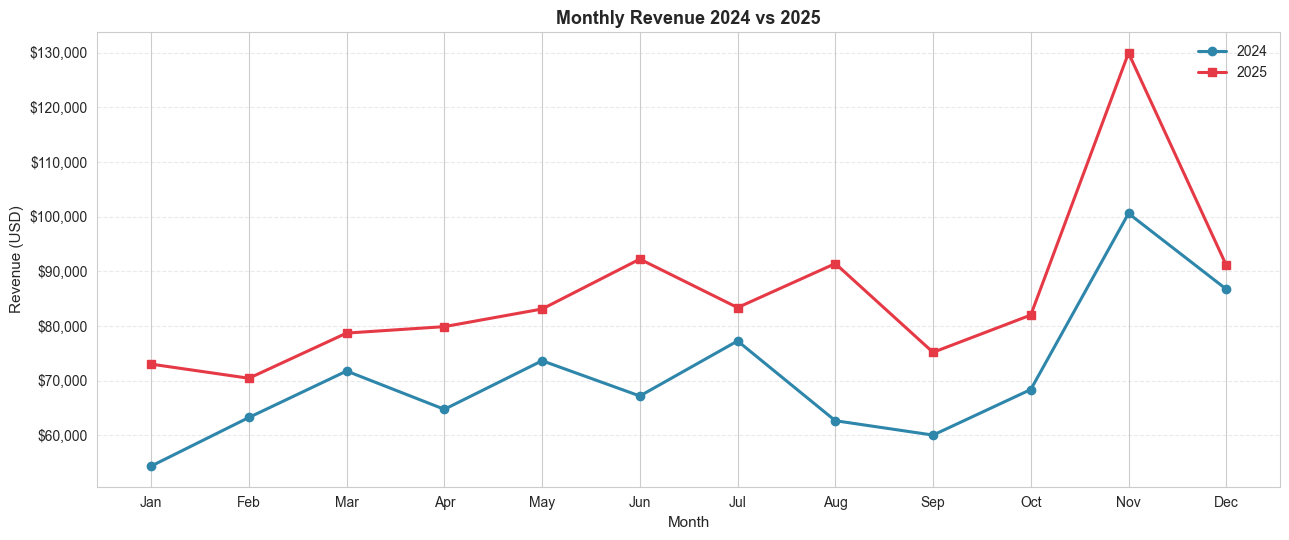

In [147]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(pivot.index, pivot[2024], marker="o", linewidth=2.2, label="2024", color="#2E86AB")
ax.plot(pivot.index, pivot[2025], marker="s", linewidth=2.2, label="2025", color="#E63946")

ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_title("Monthly Revenue 2024 vs 2025")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{Charts}/01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2 — Revenue by category

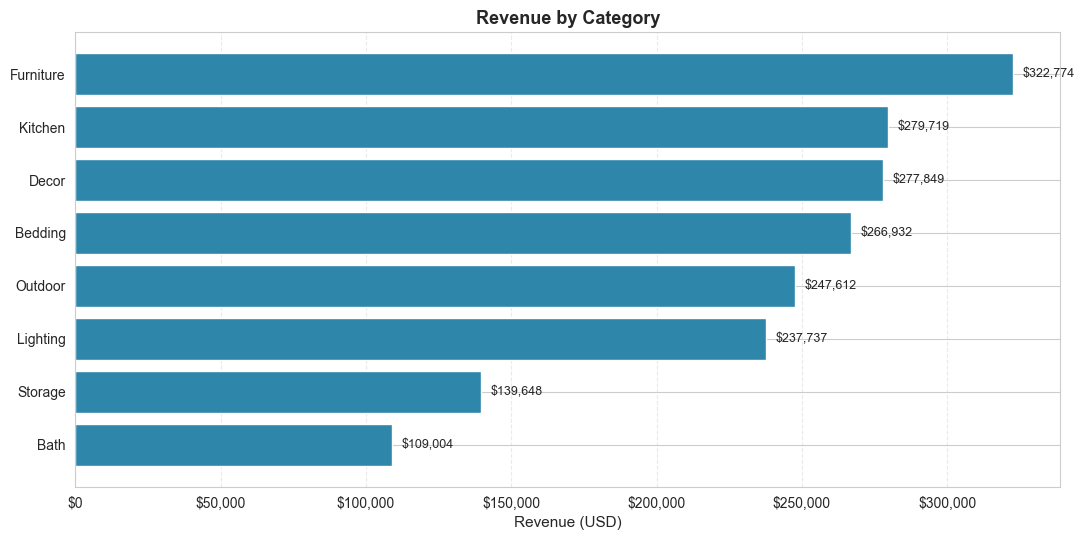

In [149]:
fig, ax = plt.subplots(figsize=(11, 5.5))

bars = ax.barh(cat_rev["category"], cat_rev["revenue"], color="#2E86AB", edgecolor="white")

ax.invert_yaxis()
ax.set_xlabel("Revenue (USD)")
ax.set_title("Revenue by Category")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.4)

for bar, val in zip(bars, cat_rev["revenue"]):
    ax.text(
        bar.get_width() + cat_rev["revenue"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(f"{Charts}/02_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3 — Return and cancel rates

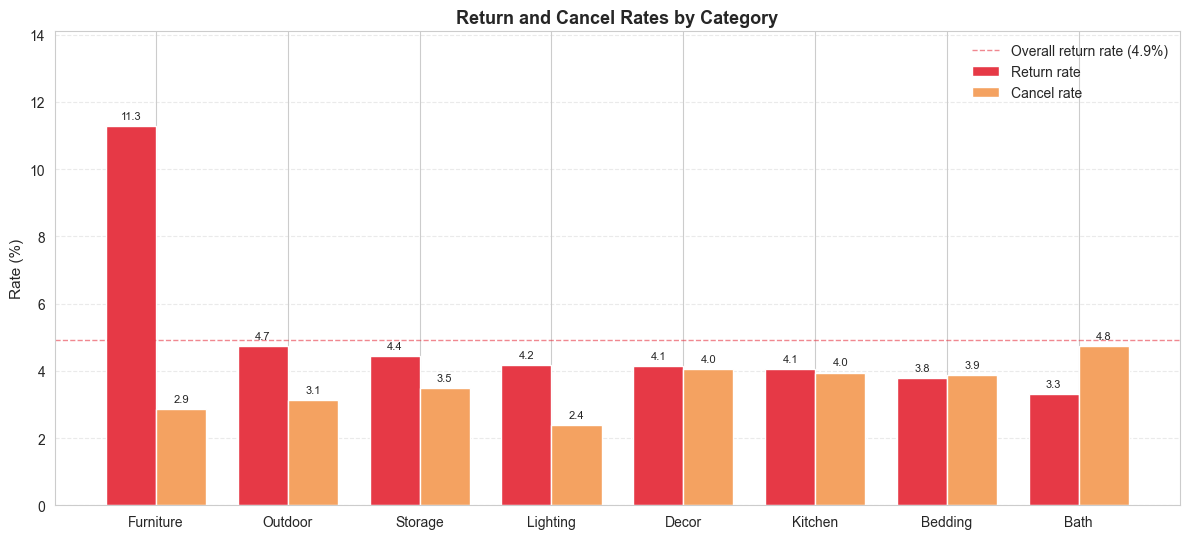

In [150]:
rates = cat_status[["return_rate", "cancel_rate"]].sort_values("return_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5.5))

x = np.arange(len(rates))
w = 0.38

bars_return = ax.bar(x - w/2, rates["return_rate"], w,
                     label="Return rate", color="#E63946", edgecolor="white")
bars_cancel = ax.bar(x + w/2, rates["cancel_rate"], w,
                     label="Cancel rate", color="#F4A261", edgecolor="white")

ax.axhline(overall_ret, color="#E63946", linestyle="--", linewidth=1,
           alpha=0.6, label=f"Overall return rate ({overall_ret:.1f}%)")

ax.set_xticks(x)
ax.set_xticklabels(rates.index)
ax.set_ylabel("Rate (%)")
ax.set_title("Return and Cancel Rates by Category")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars_return:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8)

for bar in bars_cancel:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, rates.values.max() * 1.25)

plt.tight_layout()
plt.savefig(f"{Charts}/03_return_cancel_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 4 — AOV by category

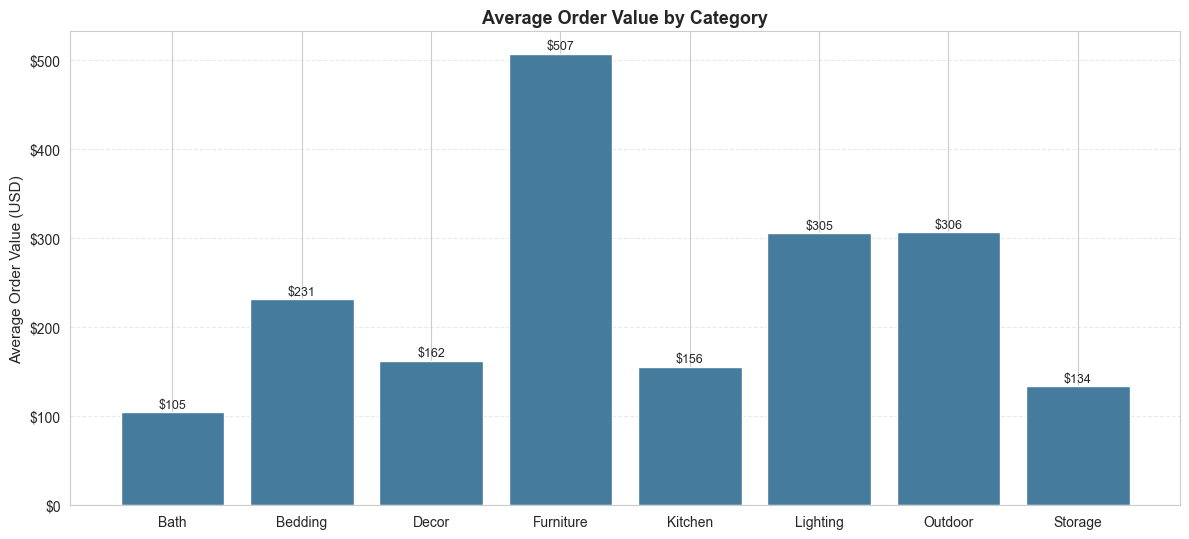

In [153]:
fig, ax = plt.subplots(figsize=(12, 5.5))

bars = ax.bar(aov_by_cat.index, aov_by_cat["avg_order_value"], color="#457B9D", edgecolor="white")

ax.set_ylabel("Average Order Value (USD)")
ax.set_title("Average Order Value by Category")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar, val in zip(bars, aov_by_cat["avg_order_value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"${val:,.0f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(f"{Charts}/04_aov_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 5 — Category mix over time

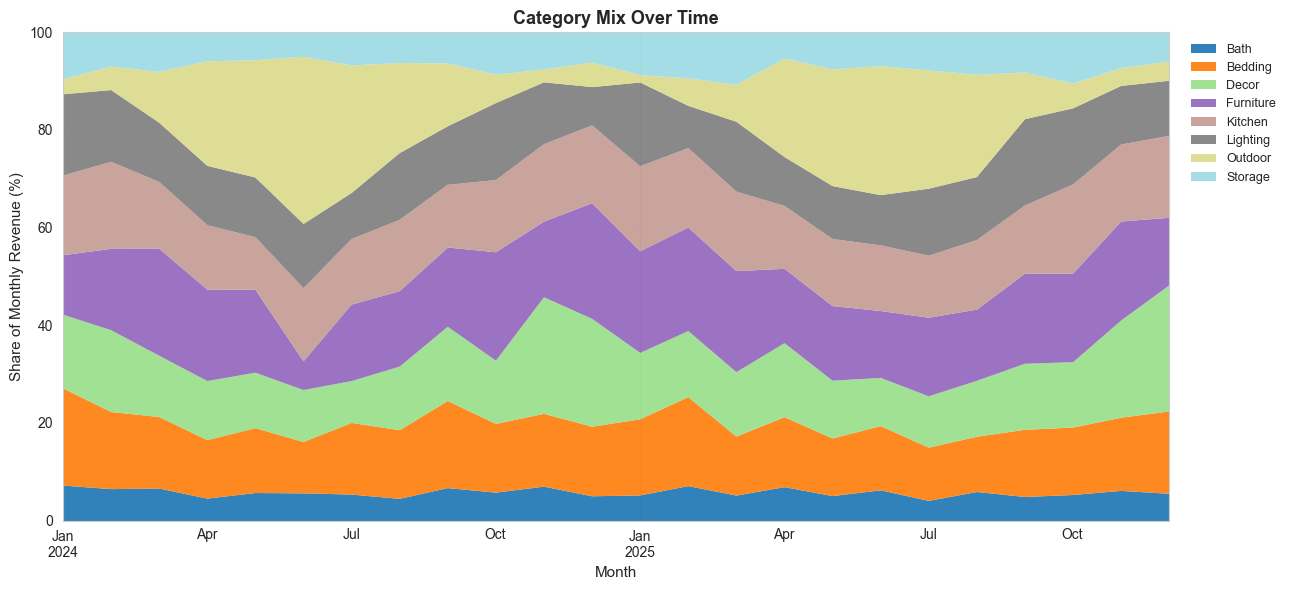

In [152]:
fig, ax = plt.subplots(figsize=(13, 6))

cat_month_pct.plot(
    kind="area",
    stacked=True,
    ax=ax,
    colormap="tab20",
    alpha=0.92,
    linewidth=0,
)

ax.set_ylabel("Share of Monthly Revenue (%)")
ax.set_xlabel("Month")
ax.set_title("Category Mix Over Time")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Charts}/05_category_mix.png", dpi=150, bbox_inches="tight")
plt.show()

## Extra checks — Profit margin by category

In [154]:
completed_margin = completed.copy()
completed_margin["line_cost"]   = completed_margin["quantity"] * completed_margin["unit_cost"]
completed_margin["line_profit"] = completed_margin["line_revenue"] - completed_margin["line_cost"]

margin_by_cat = (
    completed_margin
    .groupby("category")
    .agg(
        revenue=("line_revenue", "sum"),
        cost=("line_cost", "sum"),
        profit=("line_profit", "sum"),
    )
    .reset_index()
)

margin_by_cat["margin_pct"] = (margin_by_cat["profit"] / margin_by_cat["revenue"] * 100).round(2)
margin_by_cat = margin_by_cat.sort_values("margin_pct", ascending=False)

print("Profit margin by category:")
display(margin_by_cat.round(2))

Profit margin by category:


,category,revenue,cost,profit,margin_pct
7,Storage,"139,648.40","62,031.69","77,616.71",55.58
2,Decor,"277,848.70","135,615.07","142,233.63",51.19
1,Bedding,"266,931.61","130,362.12","136,569.49",51.16
6,Outdoor,"247,612.23","123,976.87","123,635.36",49.93
5,Lighting,"237,737.13","124,826.18","112,910.95",47.49
4,Kitchen,"279,719.21","147,408.87","132,310.34",47.30
0,Bath,"109,003.59","58,011.58","50,992.01",46.78
3,Furniture,"322,774.21","173,793.64","148,980.57",46.16


## Extra checks — Discount impact

In [170]:
disc = completed.copy()
disc["has_discount"] = disc["discount_amount"] > 0

disc_summary = (
    disc
    .groupby("has_discount")
    .agg(
        lines=("order_id", "count"),
        revenue=("line_revenue", "sum"),
        avg_line=("line_revenue", "mean"),
    )
    .round(2)
)

print("Discounted vs non discounted lines:")
display(disc_summary)

Discounted vs non discounted lines:


,lines,revenue,avg_line
has_discount,,,
False,12119,"1,649,638.74",136.12
True,2164,"231,636.34",107.04


## Extra checks — Acquisition channel value

In [156]:
channel_rev = (
    completed
    .groupby("order_id")
    .agg(
        total_revenue=("line_revenue", "sum"),
        channel=("acquisition_channel", "first"),
        customer=("customer_id", "first"),
    )
    .reset_index()
)

channel_summary = (
    channel_rev
    .groupby("channel")
    .agg(
        orders=("order_id", "count"),
        customers=("customer", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_order=("total_revenue", "mean"),
    )
    .round(2)
    .sort_values("revenue", ascending=False)
)

print("Revenue by acquisition channel:")
display(channel_summary)

Revenue by acquisition channel:


,orders,customers,revenue,avg_order
channel,,,,
organic_search,3458,741,"773,355.01",223.64
paid_search,1261,327,"290,267.46",230.19
referral,1247,248,"273,987.76",219.72
email,1132,271,"241,789.09",213.59
paid_social,1051,367,"238,330.70",226.77
affiliate,307,93,"63,545.06",206.99


## Extra checks — Top states by revenue

In [157]:
state_rev = (
    completed
    .groupby("state")
    .agg(revenue=("line_revenue", "sum"), orders=("order_id", "nunique"))
    .round(2)
    .sort_values("revenue", ascending=False)
    .head(10)
)

print("Top 10 states by revenue:")
display(state_rev)

Top 10 states by revenue:


,revenue,orders
state,,
CA,"256,447.46",1177
NY,"156,658.91",683
TX,"150,104.01",682
FL,"140,900.39",614
PA,"84,258.41",388
MI,"82,426.23",359
VA,"76,517.21",313
IL,"71,969.76",345
OH,"64,407.13",300


## Export analysis tables

In [158]:
monthly.to_csv(f"{Clean}/monthly_revenue.csv", index=False)
cat_rev.to_csv(f"{Clean}/category_performance.csv", index=False)
top_products.to_csv(f"{Clean}/top_products.csv", index=False)
cat_status.to_csv(f"{Clean}/category_status_rates.csv")
aov_by_cat.to_csv(f"{Clean}/aov_by_category.csv")
margin_by_cat.to_csv(f"{Clean}/category_margins.csv", index=False)
channel_summary.to_csv(f"{Clean}/channel_summary.csv")

print(f"Analysis tables exported to {Clean}")

Analysis tables exported to C:/Users/vinay/OneDrive/Desktop/Data Science and Analytics Projects/Wayfair Sales Analysis/Data/Cleaned Data


## Summary numbers

In [159]:
top_cat            = cat_rev.iloc[0]
highest_return_cat = cat_status["return_rate"].idxmax()
highest_return_val = cat_status["return_rate"].max()
other_rets         = cat_status.loc[cat_status.index != highest_return_cat, "return_rate"]
overall_aov        = order_rev["total_revenue"].mean()
best_month_2025    = pivot[2025].idxmax()
worst_month_2025   = pivot[2025].idxmin()
top_channel        = channel_summary.index[0]

print("=" * 62)
print("Summary Numbers")
print("=" * 62)
print(f"2024 revenue            : ${total_2024:,.2f}")
print(f"2025 revenue            : ${total_2025:,.2f}")
print(f"YoY growth              : {yoy:+.2f}%")
print(f"Months 2025 beat 2024   : {months_won} of 12")
print(f"Completed orders        : {len(order_rev):,}")
print(f"Overall AOV             : ${overall_aov:,.2f}")
print(f"Top category            : {top_cat['category']} (${top_cat['revenue']:,.2f}, {top_cat['revenue_pct']:.1f}%)")
print(f"Highest AOV category    : {aov_by_cat['avg_order_value'].idxmax()} (${aov_by_cat['avg_order_value'].max():,.2f})")
print(f"Highest return category : {highest_return_cat} ({highest_return_val:.2f}%)")
print(f"Other cats return range : {other_rets.min():.2f}% to {other_rets.max():.2f}%")
print(f"Best month 2025         : {best_month_2025} (${pivot[2025].max():,.2f})")
print(f"Worst month 2025        : {worst_month_2025} (${pivot[2025].min():,.2f})")
print(f"Top acquisition channel : {top_channel}")
print("=" * 62)

Summary Numbers
2024 revenue            : $850,786.45
2025 revenue            : $1,030,488.63
YoY growth              : +21.12%
Months 2025 beat 2024   : 12 of 12
Completed orders        : 8,456
Overall AOV             : $222.48
Top category            : Furniture ($322,774.21, 17.2%)
Highest AOV category    : Furniture ($506.78)
Highest return category : Furniture (11.28%)
Other cats return range : 3.31% to 4.73%
Best month 2025         : Nov ($129,934.23)
Worst month 2025        : Feb ($70,451.19)
Top acquisition channel : organic_search


## Summary — Key findings and recommendations

### Three key findings

**1. Revenue grew 21 percent year over year, and the growth was broad based.** 2024 closed at 850,786 dollars and 2025 at 1,030,489. Every single month of 2025 beat its 2024 counterpart, which means the growth is not a holiday season story. Both years share the same seasonal shape. A summer lift, a September dip, a sharp November spike that is the single strongest month by a wide margin, and a December ease off. November 2025 came in at 129,934 dollars against 100,587 in 2024, so the holiday window itself is growing faster than the rest of the year.

**2. Furniture is the top revenue category and the biggest margin risk.** Furniture generated 322,774 dollars, about 17 percent of total revenue, driven by a handful of high ticket bestsellers like the Cotton Patio Chair and the Classic Dining Chair Pair. It also carries the highest average order value at 506.78 dollars per order, more than 1.6 times the next category. But it has the highest return rate at 11.77 percent, roughly three times every other category which all sit between 3.86 and 5.07 percent. Bulky, high value furniture is the standout risk. It drives outsized revenue per order and outsized reversals, which likely means outsized shipping and restocking cost per return too.

**3. Category mix rotates seasonally rather than staying constant.** Outdoor products peak in spring and summer and nearly disappear in winter. Decor and Furniture do the opposite, expanding sharply in November and December. A category's average yearly share understates how concentrated its real selling window is. The merchandising team should plan inventory around the rotation, not the annual average.

### Two recommendations

**1. Investigate and fix the Furniture return rate before scaling it further.** Furniture is the top revenue driver and the clear outlier on returns. Even a modest improvement would help. Better size and fit information, sturdier packaging, clearer assembly instructions. Returns on bulky furniture carry higher reverse logistics cost than a returned bath mat. Every point shaved off that return rate protects a meaningful share of total revenue and cuts the logistics cost on the way back. This is the single highest leverage fix available for next year's margin.

**2. Plan inventory and marketing around the seasonal rotation, not the annual average.** Build Outdoor inventory ahead of spring. Build Decor and Furniture inventory ahead of November. Shift acquisition spend into those windows. November is already the year's biggest opportunity and it grew faster than the baseline in 2025, so any inventory and marketing that lands in that window compounds on top of the natural lift.